<a href="https://colab.research.google.com/github/muneer-ahmad10/End_Module_exam_prep/blob/main/Weak_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NLP & Word Embeddings**

### **Why raw text can't go directly into a neural network**

Models work on numbers, not words. So before any NLP model can process text, you need to convert words/tokens into numeric representations.

### **Bag-of-Words / One-Hot Encoding (the naive approach):**

Each word gets a unique index; a sentence becomes a vector of 0s and 1s (or counts) the size of the entire vocabulary. Problems: huge sparse vectors, no notion of meaning or similarity — "king" and "queen" are just as unrelated as "king" and "banana" in this representation.

### **Word Embeddings (the fix):**

Each word is mapped to a dense, low-dimensional vector (e.g. 100–300 dimensions) learned such that semantically similar words end up close together in that vector space. Classic exam fact: the famous analogy king - man + woman ≈ queen works because embeddings capture relational structure, not just identity.

### **How embeddings are learned — Word2Vec intuition**

Two common training setups:

**CBOW (Continuous Bag of Words):** predict the target word from its surrounding context words

**Skip-gram:** predict the surrounding context words from a single target word

Both rely on the core assumption behind embeddings: words that appear in similar contexts tend to have similar meaning ("distributional hypothesis"). You don't need the full derivation — just know the direction of prediction differs (CBOW: context→word, Skip-gram: word→context), since this exact distinction is a common MCQ trap.

### **Unsupervised Text Embedding & Classification**

This connects embeddings to a downstream task:

* Convert each document/sentence into a vector — often by averaging (or otherwise pooling) the word embeddings of all tokens in it

* Feed that single vector into a classifier (could be as simple as logistic regression, or a small neural net)

* "Unsupervised" refers to how the embeddings themselves were learned (no labels needed to train Word2Vec) — the classification step on top is typically supervised (needs labeled data)

***the embedding step is unsupervised; the classification step using those embeddings is usually supervised. Don't confuse "unsupervised text embedding" with "the whole pipeline is unsupervised."***

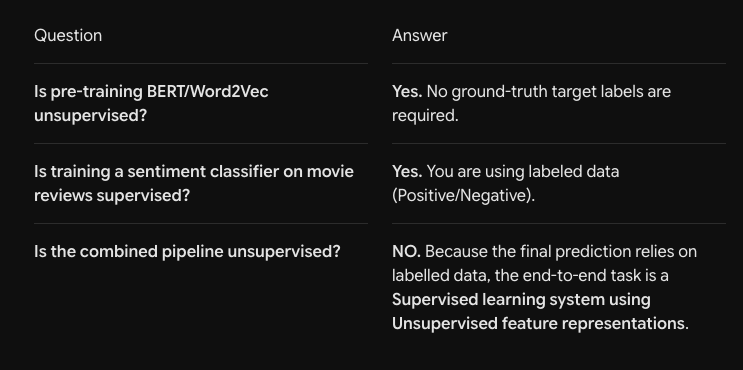

# **Sentiment Classification**

A specific, common application: predict whether text expresses positive/negative (sometimes neutral) sentiment.

### **Typical pipeline:**

Raw text → Tokenize → Embed tokens → Pool/aggregate into one vector
→ Classifier (Linear + softmax/sigmoid) → Sentiment label

* Binary sentiment (positive/negative): use sigmoid output + BCELoss (binary cross-entropy)
* Multi-class sentiment (positive/neutral/negative): use softmax output + CrossEntropyLoss

*Why can't one-hot encoded word vectors capture semantic similarity between words, even in principle?*

One-hot vectors are just an on/off switch per word — every word is equidistant from every other word (mathematically, the cosine similarity or dot product between any two different one-hot vectors is always 0). There's no shared structure between "king" and "queen" any more than between "king" and "banana" — the representation has no way to encode relatedness, only identity.

*In Skip-gram, is the model predicting the context from the word, or the word from the context?*

Skip-gram: word → predicts context. (CBOW is the reverse: context → predicts word.)

*If you're averaging word embeddings to represent a whole sentence, what's a potential weakness of this approach (think about word order)?*



Averaging embeddings destroys sequence/order information — "I love you" and "you love I" would produce the identical averaged vector, even though they mean very different things. This is exactly why later models (RNN/LSTM, and especially Transformers with positional encoding) exist — they preserve order, while simple averaging throws it away completely. Good connection to make

*Why would you use BCELoss + sigmoid for binary sentiment but CrossEntropyLoss + softmax for 3-class sentiment?*

sigmoid outputs a single independent probability (good for "is it class 1, yes/no" — one number), while softmax outputs a full probability distribution across multiple classes that all sum to 1 (each class's probability depends on the others — raising one lowers the rest). For binary classification, you technically could use softmax with 2 output classes and it would work equivalently to sigmoid — but sigmoid+BCELoss is simpler and standard for 2-class problems, while softmax+CrossEntropyLoss is required once you have 3+ mutually exclusive classes, since sigmoid alone doesn't naturally support "pick exactly one out of N>2 categories" the way softmax's competing-normalization does.

# **Attention, Encoder-Decoder, BERT/GPT, Transformer Pipelines**

### **The problem attention solves (recall from RNN/LSTM)**

RNN/LSTM-based encoder-decoder models compress an entire input sequence into one fixed-size context vector, then the decoder generates output from just that single vector. For long sequences, this is a severe bottleneck — a 50-word sentence and a 5-word sentence get squeezed into the same-sized vector, and information from early words tends to get lost by the time the sequence ends.

### **Attention mechanism — the core idea**

Instead of relying on one compressed vector, attention lets the decoder look back at all encoder hidden states at every generation step, and learn which ones matter most for the current output word.

### **Query, Key, Value (Q/K/V) — the mechanism itself:**

* Query (Q): "what am I looking for right now?" — comes from the current decoding step
* Key (K): "what does each input position offer?" — comes from each encoder position
* Value (V): "the actual content to retrieve" — also from each encoder position

### **The computation:**

* Compute similarity scores between the Query and every Key (commonly via dot product)
* Apply softmax to those scores → turns them into attention weights that sum to 1
* Compute a weighted sum of the Values, using those attention weights

This produces a context vector that's a weighted blend of all input positions, where the weights reflect relevance to the current query — instead of one fixed vector for the entire sequence, you get a dynamic one that shifts depending on what's being generated.

### **Summary Equation Cheat Sheet for Exams**
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
  $$$QK^T$: Dot product measuring similarity between Query and Keys.$\sqrt{d_k}$: Scaling factor (prevents gradients from vanishing/exploding when dimensions grow large).$\text{softmax}(\dots)$: Turns similarity scores into attention weights that sum to 1.$\times V$: Blends the actual content based on those weights.

### **Encoder-Decoder Architecture**

***The General pattern:***

Input sequence → ENCODER → contextualized representations → DECODER → Output sequence

* **Encoder:** processes the entire input sequence and produces a representation for each position (with attention, these representations already incorporate context from the whole sequence, not just what came before)
* **Decoder:** generates the output sequence one token at a time, using both (a) what it's generated so far, and (b) attention over the encoder's representations

**Classic use case:** machine translation. Encoder reads the full source sentence (e.g. English), decoder generates the target sentence (e.g. French) word by word, attending back to relevant English words at each step.